In [59]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

dataset = pd.read_csv('GoodsOrder.csv', encoding='GBK')

data = pd.get_dummies(dataset, prefix = '', prefix_sep = '')
data = data.groupby('id').sum()
print(data)

      一般清洁剂  一般肉类  一般饮料  人造黄油  仁果类水果  保管产品  保鲜膜/袋  全脂牛奶  其他蔬菜  其他饮料  ...  餐巾  \
id                                                                   ...       
1         0     0     0     1      0     0      0     0     0     0  ...   0   
2         0     0     0     0      0     0      0     0     0     0  ...   0   
3         0     0     0     0      0     0      0     1     0     0  ...   0   
4         0     0     0     0      1     0      0     0     0     0  ...   0   
5         0     0     0     0      0     0      0     1     1     0  ...   0   
...     ...   ...   ...   ...    ...   ...    ...   ...   ...   ...  ...  ..   
9831      0     0     0     0      0     0      0     1     0     0  ...   1   
9832      0     0     0     0      0     0      0     0     0     0  ...   0   
9833      0     0     0     0      0     0      1     0     1     0  ...   0   
9834      0     0     0     0      0     0      0     0     0     0  ...   0   
9835      0     0     0     0      0    

In [60]:
data = data.sum(0)
data = pd.DataFrame(data, columns = ['numbers'])
hot_goods = data.sort_values('numbers', ascending = False)
top10_goods = hot_goods.head(10)
print(top10_goods)

       numbers
全脂牛奶      2513
其他蔬菜      1903
面包卷       1809
苏打        1715
酸奶        1372
瓶装水       1087
根茎类蔬菜     1072
热带水果      1032
购物袋        969
香肠         924


<BarContainer object of 10 artists>

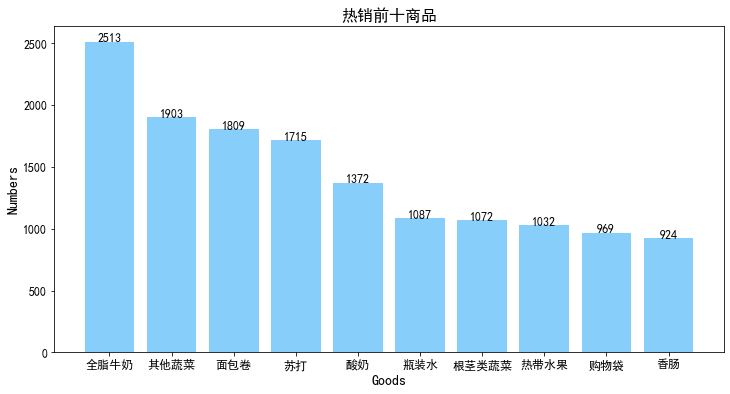

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False   # 解决中文显示问题
plt.title('热销前十商品', fontsize=16)
plt.xlabel('Goods', fontsize=14)
plt.ylabel('Numbers', fontsize=14)
plt.tick_params(labelsize=12)
[plt.text(x, int(y), s=int(y), ha='center', fontsize=12) for x, y in zip(top10_goods.index, top10_goods.values)]
plt.bar(top10_goods.index, [int(x) for x in top10_goods.values], color='#87CEFA')

([<matplotlib.patches.Wedge at 0x2bc0ecd0250>,
 [Text(1.0818227206109385, 0.1991471846899864, '全脂牛奶'),
  Text(0.964310254855606, 0.5292501604915361, '其他蔬菜'),
  Text(0.7890464082272224, 0.766424011669598, '面包卷'),
  Text(0.569935590953923, 0.9408365544365306, '苏打'),
  Text(0.3470951444187186, 1.0438031235443537, '酸奶'),
  Text(0.15664670624382207, 1.0887891482849017, '瓶装水'),
  Text(-0.014861026028267655, 1.0998996090122894, '根茎类蔬菜'),
  Text(-0.18168488060532353, 1.0848919781063133, '热带水果'),
  Text(-0.3364913447156402, 1.047269580829817, '购物袋'),
  Text(-0.47649761188663614, 0.9914383621114995, '香肠'),
  Text(-0.5541123995462246, -0.9502417843207724, '其它商品')],
 [Text(0.5900851203332391, 0.10862573710362894, '5.79%'),
  Text(0.5259874117394213, 0.288681905722656, '4.39%'),
  Text(0.43038894994212124, 0.41804946091068973, '4.17%'),
  Text(0.31087395870213974, 0.5131835751471985, '3.95%'),
  Text(0.18932462422839194, 0.5693471582969201, '3.16%'),
  Text(0.08544365795117566, 0.5938849899735827, 

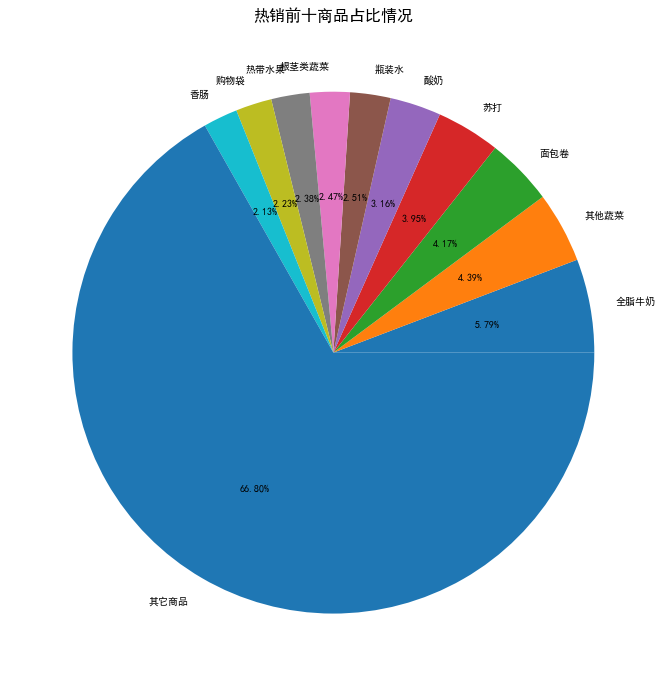

In [62]:
plt.figure(figsize=(12, 12))
plt.title('热销前十商品占比情况', fontsize=16)
plt.tick_params(labelsize=12)
values = [int(x) for x in top10_goods.values] + [hot_goods.sum() - top10_goods.sum()]
index = [x for x in top10_goods.index] + ['其它商品']
plt.pie(values, labels=index, autopct='%.2f%%')

In [63]:
type_map = pd.read_csv('GoodsTypes.csv', encoding='GBK')
goods_type = {type_map['Goods'][x]: type_map['Types'][x]
              for x in range(len(type_map))}

hot_type = {x: 0 for x in set(goods_type.values())}
for x, y in goods_type.items():
    if x in hot_goods.index:
        hot_type[y] += hot_goods['numbers'][x]

data_type = pd.DataFrame(columns=[['Types', 'Numbers']])
data_type[['Types']], data_type[['Numbers']] = pd.DataFrame(
    hot_type.keys()), pd.DataFrame(hot_type.values())
print(hot_type)
print(data_type)

{'西点': 7192, '非酒精饮料': 7594, '果蔬': 7146, '熟食': 541, '米粮调料': 5185, '百货': 5141, '食品类': 1870, '零食': 1459, '肉类': 4870, '酒精饮料': 2287}
   Types Numbers
0     西点    7192
1  非酒精饮料    7594
2     果蔬    7146
3     熟食     541
4   米粮调料    5185
5     百货    5141
6    食品类    1870
7     零食    1459
8     肉类    4870
9   酒精饮料    2287


<BarContainer object of 10 artists>

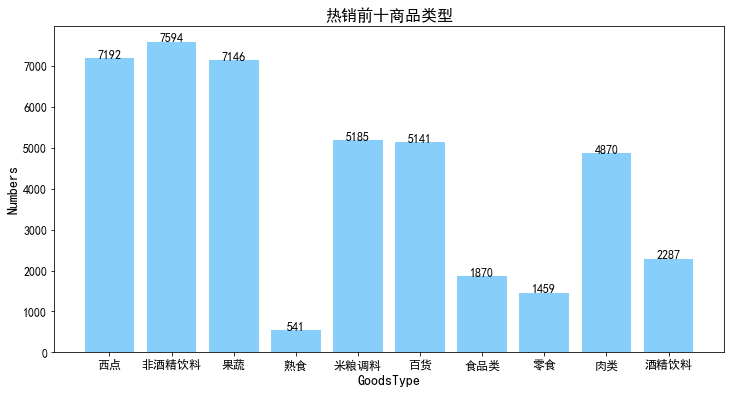

In [64]:
plt.figure(figsize=(12, 6))

plt.title('热销前十商品类型', fontsize=16)
plt.xlabel('GoodsType', fontsize=14)
plt.ylabel('Numbers', fontsize=14)
plt.tick_params(labelsize=12)
[plt.text(x, int(y), s=int(y), ha='center', fontsize=12)
 for x, y in hot_type.items()]
plt.bar(data_type[['Types']].values.flatten(),
        data_type[['Numbers']].values.flatten(), color='#87CEFA')

([<matplotlib.patches.Wedge at 0x2bc0fab4820>,
 [Text(0.9535115618141129, 0.5484666822030407, '西点'),
  Text(-0.026782793225928275, 1.0996738980202345, '非酒精饮料'),
  Text(-0.977401777459046, 0.5046640124081542, '果蔬'),
  Text(-1.0963676724743516, -0.0893192406661247, '熟食'),
  Text(-0.9669827834170811, -0.5243513102634098, '米粮调料'),
  Text(-0.35068242334173777, -1.042603394373511, '百货'),
  Text(0.20167900284393422, -1.0813535868585615, '食品类'),
  Text(0.4545586802572808, -1.0016867804871736, '零食'),
  Text(0.8515557786668515, -0.6963136906733145, '肉类'),
  Text(1.08488102026606, -0.18175030087037777, '酒精饮料')],
 [Text(0.5200972155349707, 0.2991636448380222, '16.62%'),
  Text(-0.014608796305051784, 0.5998221261928551, '17.54%'),
  Text(-0.5331282422503887, 0.2752712794953568, '16.51%'),
  Text(-0.5980187304405553, -0.0487195858178862, '1.25%'),
  Text(-0.5274451545911351, -0.2860098055982235, '11.98%'),
  Text(-0.19128132182276603, -0.5686927605673695, '11.88%'),
  Text(0.1100067288239641, -0.589

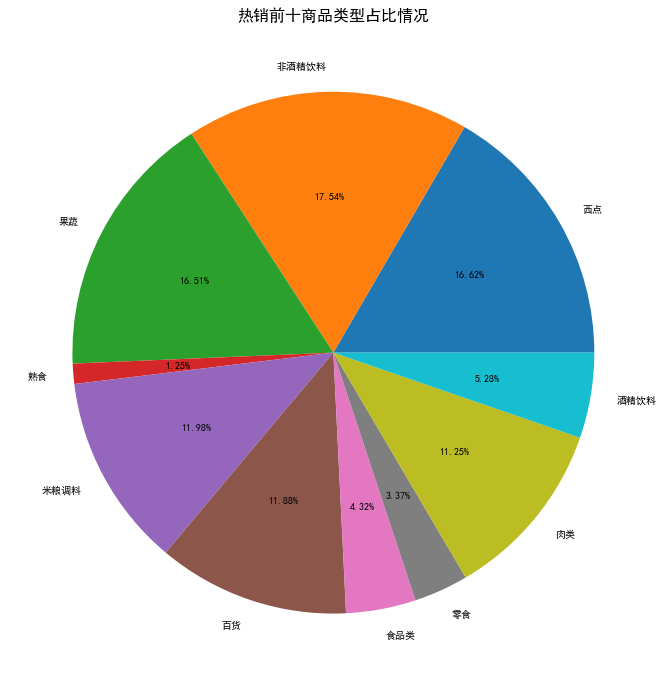

In [65]:
plt.figure(figsize=(12, 12))
plt.title('热销前十商品类型占比情况', fontsize=16)
plt.tick_params(labelsize=20)
plt.pie(data_type[['Numbers']].values.flatten(),
        labels=data_type[['Types']].values.flatten(), autopct='%.2f%%')

In [66]:
from mlxtend.frequent_patterns import apriori, association_rules
dataset = pd.read_csv('GoodsOrder.csv', encoding='GBK')

data = pd.get_dummies(dataset, prefix = '', prefix_sep = '')
data = data.groupby('id').sum()
frequent_itemsets = apriori(data, min_support=0.055, use_colnames=True)
print(frequent_itemsets)

rules = association_rules(
    frequent_itemsets, metric='confidence', min_threshold=0.05)
print(rules)

     support      itemsets
0   0.058566        (人造黄油)
1   0.075648       (仁果类水果)
2   0.255516        (全脂牛奶)
3   0.193493        (其他蔬菜)
4   0.058973       (冷冻热狗肠)
5   0.058058          (咖啡)
6   0.079817          (报纸)
7   0.063447        (本地蛋类)
8   0.082766       (柑橘类水果)
9   0.108998       (根茎类蔬菜)
10  0.072293      (水果/蔬菜汁)
11  0.104931        (热带水果)
12  0.057651          (猪肉)
13  0.080529        (瓶装啤酒)
14  0.110524         (瓶装水)
15  0.088968          (糕点)
16  0.077682        (罐装啤酒)
17  0.174377          (苏打)
18  0.098526         (购物袋)
19  0.139502          (酸奶)
20  0.071683         (酸奶油)
21  0.183935         (面包卷)
22  0.093950          (香肠)
23  0.055414          (黄油)
24  0.064870         (黑面包)
25  0.074835  (其他蔬菜, 全脂牛奶)
26  0.056024    (全脂牛奶, 酸奶)
27  0.056634   (面包卷, 全脂牛奶)
  antecedents consequents  antecedent support  consequent support   support  \
0      (其他蔬菜)      (全脂牛奶)            0.193493            0.255516  0.074835   
1      (全脂牛奶)      (其他蔬菜)            0.255516            0.

In [67]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets_fp = fpgrowth(data, min_support=0.055, use_colnames=True)
print(frequent_itemsets_fp)

rules_fp = association_rules(
    frequent_itemsets_fp, metric='confidence', min_threshold=0.05)
print(rules_fp)


     support      itemsets
0   0.082766       (柑橘类水果)
1   0.058566        (人造黄油)
2   0.139502          (酸奶)
3   0.104931        (热带水果)
4   0.058058          (咖啡)
5   0.255516        (全脂牛奶)
6   0.075648       (仁果类水果)
7   0.193493        (其他蔬菜)
8   0.055414          (黄油)
9   0.183935         (面包卷)
10  0.080529        (瓶装啤酒)
11  0.110524         (瓶装水)
12  0.174377          (苏打)
13  0.058973       (冷冻热狗肠)
14  0.079817          (报纸)
15  0.072293      (水果/蔬菜汁)
16  0.088968          (糕点)
17  0.108998       (根茎类蔬菜)
18  0.077682        (罐装啤酒)
19  0.093950          (香肠)
20  0.098526         (购物袋)
21  0.064870         (黑面包)
22  0.071683         (酸奶油)
23  0.057651          (猪肉)
24  0.063447        (本地蛋类)
25  0.056024    (全脂牛奶, 酸奶)
26  0.074835  (其他蔬菜, 全脂牛奶)
27  0.056634   (面包卷, 全脂牛奶)
  antecedents consequents  antecedent support  consequent support   support  \
0      (全脂牛奶)        (酸奶)            0.255516            0.139502  0.056024   
1        (酸奶)      (全脂牛奶)            0.139502            0.

In [72]:
dataset_type = dataset.copy()
dataset_type['Goods'] = dataset_type['Goods'].map(goods_type)
dataset_type = pd.get_dummies(dataset_type, prefix='', prefix_sep='')
dataset_type = dataset_type.groupby('id').sum()
print(dataset_type)

for x in dataset_type.columns:
    dataset_type[x] = dataset_type[x].map(lambda x: 0 if x == 0 else 1)

print(dataset_type)

      果蔬  熟食  百货  米粮调料  肉类  西点  酒精饮料  零食  非酒精饮料  食品类
id                                                  
1      1   1   0     1   0   1     0   0      0    0
2      1   0   0     0   0   0     0   0      1    1
3      0   0   0     0   0   0     0   0      1    0
4      1   0   0     0   1   1     0   0      0    1
5      1   0   0     1   0   1     0   0      1    0
...   ..  ..  ..   ...  ..  ..   ...  ..    ...  ...
9831   3   0   2     3   4   1     1   1      2    0
9832   0   0   0     1   0   0     0   0      0    0
9833   2   0   1     1   3   1     1   0      0    1
9834   0   0   0     0   0   1     1   0      2    0
9835   2   0   1     1   1   0     0   0      0    0

[9835 rows x 10 columns]
      果蔬  熟食  百货  米粮调料  肉类  西点  酒精饮料  零食  非酒精饮料  食品类
id                                                  
1      1   1   0     1   0   1     0   0      0    0
2      1   0   0     0   0   0     0   0      1    1
3      0   0   0     0   0   0     0   0      1    0
4      1   0   0    

In [ ]:
type_fi = apriori(dataset_type, min_support=0.25, use_colnames=True)
print(type_fi)

type_r = association_rules(type_fi, metric='confidence', min_threshold=0.2)
print(type_r)

    support     itemsets
0  0.435384         (果蔬)
1  0.379054         (百货)
2  0.345297       (米粮调料)
3  0.353940         (肉类)
4  0.480935         (西点)
5  0.543976      (非酒精饮料)
6  0.270463  (非酒精饮料, 果蔬)
7  0.299136  (非酒精饮料, 西点)
  antecedents consequents  antecedent support  consequent support   support  \
0     (非酒精饮料)        (果蔬)            0.543976            0.435384  0.270463   
1        (果蔬)     (非酒精饮料)            0.435384            0.543976  0.270463   
2     (非酒精饮料)        (西点)            0.543976            0.480935  0.299136   
3        (西点)     (非酒精饮料)            0.480935            0.543976  0.299136   

   confidence      lift  leverage  conviction  
0    0.497196  1.141972  0.033624    1.122935  
1    0.621205  1.141972  0.033624    1.203882  
2    0.549907  1.143410  0.037519    1.153237  
3    0.621987  1.143410  0.037519    1.206373  


In [ ]:
type_fi_fp = fpgrowth(dataset_type, min_support=0.25, use_colnames=True)
print(type_fi_fp)

type_r_fp = association_rules(
    type_fi_fp, metric='confidence', min_threshold=0.2)
print(type_r_fp)

    support     itemsets
0  0.480935         (西点)
1  0.435384         (果蔬)
2  0.345297       (米粮调料)
3  0.543976      (非酒精饮料)
4  0.353940         (肉类)
5  0.379054         (百货)
6  0.299136  (非酒精饮料, 西点)
7  0.270463  (非酒精饮料, 果蔬)
  antecedents consequents  antecedent support  consequent support   support  \
0     (非酒精饮料)        (西点)            0.543976            0.480935  0.299136   
1        (西点)     (非酒精饮料)            0.480935            0.543976  0.299136   
2     (非酒精饮料)        (果蔬)            0.543976            0.435384  0.270463   
3        (果蔬)     (非酒精饮料)            0.435384            0.543976  0.270463   

   confidence      lift  leverage  conviction  
0    0.549907  1.143410  0.037519    1.153237  
1    0.621987  1.143410  0.037519    1.206373  
2    0.497196  1.141972  0.033624    1.122935  
3    0.621205  1.141972  0.033624    1.203882  
